# Segmentación de Canciones de Spotify mediante Clustering

## Objetivo

El objetivo de este análisis es aplicar técnicas de aprendizaje no supervisado para identificar grupos de canciones con características musicales similares.

Para ello se utilizarán variables de audio proporcionadas por Spotify, tales como energía, danceability, tempo, acousticness y valence.

El flujo de trabajo seguirá las siguientes etapas:

1. Preprocesamiento de datos.
2. Escalamiento de variables.
3. Reducción de dimensionalidad mediante PCA.
4. Segmentación utilizando K-Means.
5. Evaluación del número óptimo de clusters.
6. Interpretación de resultados desde una perspectiva técnica y de negocio.

# Paso 0: Importar librerías y herramientas

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import DBSCAN

# Paso 1: Importar archivo csv 

In [7]:
df = pd.read_csv('spotifydataset.csv')
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


# Paso 2: Exploración inicial de datos

Se realiza una inspección preliminar del conjunto de datos para comprender:

- Cantidad de registros.
- Variables disponibles.
- Tipos de datos.
- Posibles valores faltantes.

Este paso permite identificar qué variables serán utilizadas para el análisis de clustering.

In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   str    
 2   genres             837 non-null    str    
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   str    
 6   track_name         1000 non-null   str    
 7   album_name         1000 non-null   str    
 8   release_date       1000 non-null   str    
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 non-null   i

,Unnamed: 0,followers,artist_popularity,duration_ms,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,1.150655e+07,59.429000,212368.619000,59.429000,0.611430,0.660562,5.243000,-7.160373,0.613000,0.091402,0.265840,0.074700,0.188810,0.516641,122.143448
std,288.819436,2.293890e+07,23.884963,65706.472572,23.884963,0.167246,0.207568,3.613725,4.479642,0.487307,0.090441,0.288895,0.225472,0.145454,0.232896,28.053658
min,0.000000,2.000000e+00,0.000000,51680.000000,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,249.750000,1.038784e+06,57.000000,173083.000000,57.000000,0.505500,0.539500,2.000000,-8.334250,0.000000,0.037975,0.028325,0.000000,0.095700,0.343500,99.983500
50%,499.500000,3.923159e+06,67.000000,204382.500000,67.000000,0.634000,0.680500,5.000000,-5.943500,1.000000,0.054800,0.152500,0.000004,0.129000,0.522000,122.073500
75%,749.250000,1.142132e+07,74.000000,244192.750000,74.000000,0.728250,0.820000,9.000000,-4.582500,1.000000,0.106000,0.416250,0.000586,0.246500,0.686250,138.667250
max,999.000000,1.194287e+08,92.000000,707160.000000,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


# Paso 3: Selección de variables de audio

Para la segmentación se utilizarán únicamente variables numéricas relacionadas con características musicales.

No se incluyen variables textuales como nombre de canción o artista debido a que los algoritmos de clustering trabajan sobre datos numéricos.

In [9]:
features = [
    'track_popularity',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

In [10]:
X = df[features]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Paso 4: Normalización de variables

Las variables presentan escalas muy diferentes.

Por ejemplo:

- Danceability toma valores entre 0 y 1.
- Tempo puede superar los 150 BPM.
- Loudness se expresa en decibeles negativos.

Para evitar que una variable domine el cálculo de distancias, se aplica estandarización mediante StandardScaler.

# Paso 5: Reducción de dimensionalidad mediante PCA

El conjunto de datos contiene múltiples variables que dificultan la visualización directa.

PCA (Principal Component Analysis) transforma las variables originales en componentes principales que concentran la mayor cantidad posible de información.

Esto facilita la visualización de los resultados de clustering en dos dimensiones.

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca.explained_variance_ratio_
sum(pca.explained_variance_ratio_)

np.float64(0.3768407900127038)

### Interpretación de la varianza explicada

La suma de la varianza explicada indica qué porcentaje de la información original se conserva en los componentes principales seleccionados.

Entre mayor sea este porcentaje, mejor representa el PCA la estructura original de los datos.

In [12]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

## Paso 6: Determinación del número de clusters mediante el Método del Codo

El Método del Codo evalúa cómo disminuye la inercia al aumentar el número de clusters.

La inercia mide qué tan compactos son los grupos obtenidos.

El objetivo es identificar el punto donde agregar más clusters produce mejoras cada vez menores.

Text(0.5, 1.0, 'Método del Codo')

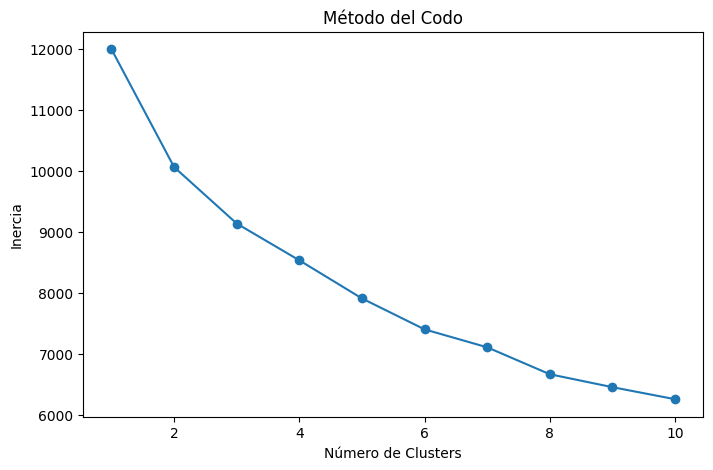

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

### Interpretación

Se observa una reducción importante de la inercia hasta aproximadamente K=3.

A partir de este punto la disminución se vuelve más gradual, sugiriendo que tres clusters representan un compromiso adecuado entre simplicidad y capacidad descriptiva.

## Paso 7: Evaluación mediante Silhouette Score

El Silhouette Score mide simultáneamente:

- Qué tan similares son las observaciones dentro de un cluster.
- Qué tan diferentes son respecto a otros clusters.

Valores cercanos a 1 indican una separación clara entre grupos.

In [14]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

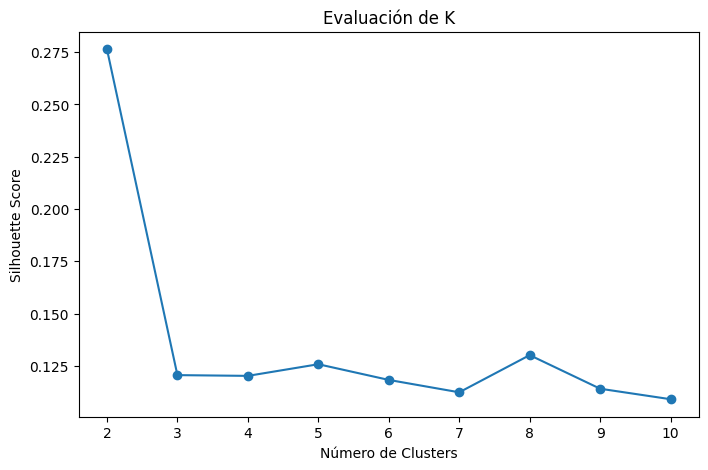

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker='o'
)

plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')
plt.title('Evaluación de K')

plt.show()


### Interpretación

El mayor valor de Silhouette se obtuvo para K=2.

Sin embargo, el análisis visual mediante PCA y la interpretación de los perfiles musicales mostraron que K=3 genera segmentos más diferenciados y útiles desde una perspectiva de negocio.

Por esta razón se seleccionó K=3 para el análisis final.

## Paso 8: Aplicación de K-Means

K-Means agrupa canciones minimizando la distancia entre observaciones dentro de cada cluster.

Se seleccionó K=3 considerando:

- Resultados del Método del Codo.
- Visualización mediante PCA.
- Interpretabilidad de los grupos obtenidos.

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [19]:
df['Cluster'] = clusters

## Paso 9: Visualización de los clusters mediante PCA

Los componentes principales permiten representar las canciones en un espacio bidimensional conservando la mayor parte de la información original.

Cada color representa un cluster identificado por K-Means, facilitando la interpretación visual de la segmentación.

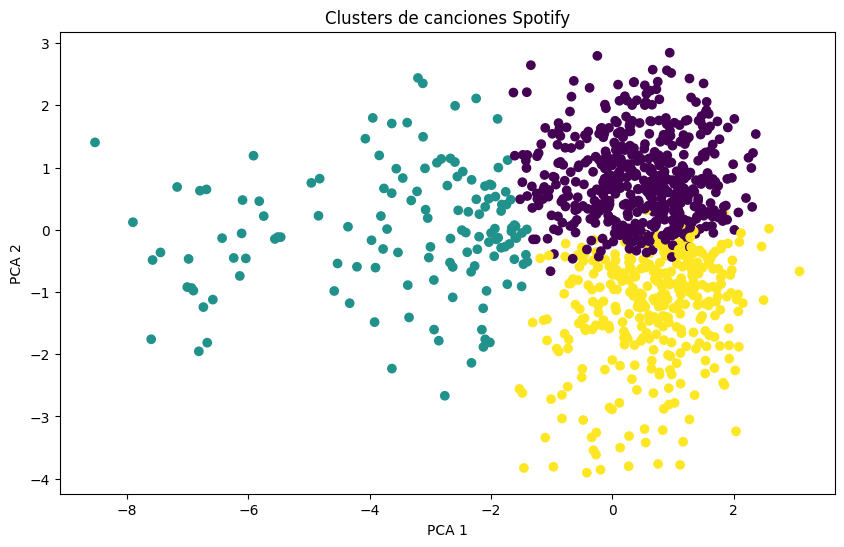

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title('Clusters de canciones Spotify')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

### Interpretación

El gráfico evidencia la formación de tres agrupaciones principales de canciones.

Aunque existe cierto solapamiento entre algunos puntos, se observa una separación suficiente para diferenciar perfiles musicales distintos, lo que respalda el uso de K-Means con tres clusters.

In [21]:
df.groupby('Cluster')[features].mean()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,64.992308,0.709831,0.660125,5.396154,-6.465690,0.503846,0.104530,0.252606,0.005062,0.145349,0.609237,113.526704
1,45.079710,0.463000,0.315523,5.224638,-14.562058,0.695652,0.053964,0.727229,0.373967,0.133055,0.323320,117.537652
2,56.760234,0.521708,0.800453,5.017544,-5.229971,0.745614,0.086547,0.099787,0.059826,0.277389,0.453859,137.103409


# Paso 10: Interpretación de los clusters

### Cluster 0: Música popular y bailable

Este grupo presenta:

- Alta popularidad.
- Alta danceability.
- Energía moderadamente alta.
- Baja instrumentalidad.

Corresponde a canciones comerciales orientadas al consumo masivo y reproducción en playlists populares.

### Cluster 1: Música acústica e instrumental

Este cluster presenta:

- Baja energía.
- Alta acousticness.
- Alta instrumentalness.
- Menor popularidad promedio.

Representa música más tranquila, instrumental o enfocada en la experiencia auditiva.

### Cluster 2: Música energética y rápida

Este grupo se caracteriza por:

- Mayor energía.
- Mayor tempo.
- Mayor volumen promedio.
- Baja acousticness.

Incluye canciones dinámicas orientadas a actividades como ejercicio, entrenamiento o entretenimiento activo.

In [22]:
kmeans2 = KMeans(
    n_clusters=2,
    random_state=42
)

clusters2 = kmeans2.fit_predict(X_scaled)

In [23]:
df['Cluster2'] = clusters2

df.groupby('Cluster2')[features].mean()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster2,,,,,,,,,,,,
0,61.746462,0.636913,0.719192,5.218160,-5.901133,0.597877,0.097942,0.187645,0.024596,0.198798,0.549701,123.092988
1,46.500000,0.469263,0.333469,5.381579,-14.185605,0.697368,0.054914,0.702085,0.354229,0.133090,0.332203,116.846013


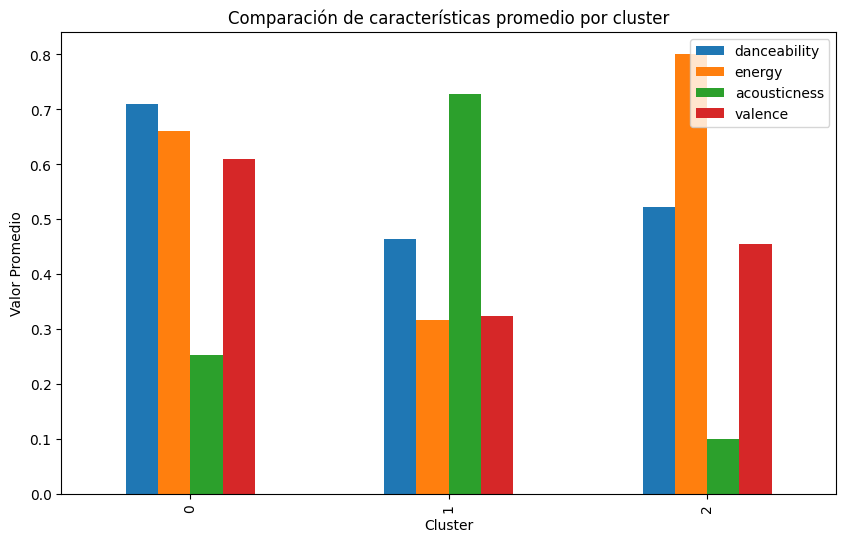

In [31]:
cluster_means = df.groupby('Cluster')[
    ['danceability','energy','acousticness','valence']
].mean()

cluster_means.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparación de características promedio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Valor Promedio")
plt.show()

### Interpretación

El gráfico compara las principales características musicales promedio de cada cluster.

Las diferencias observadas en variables como energía, danceability, acousticness y valence permiten describir claramente el perfil musical de cada grupo identificado.

# Paso 11: Selección del parámetro eps para DBSCAN

DBSCAN requiere definir un parámetro denominado eps, que representa la distancia máxima entre observaciones vecinas para considerarlas parte de una misma región densa.

Para seleccionar este valor se utiliza el gráfico K-Distance, el cual permite identificar visualmente el punto donde las distancias comienzan a incrementarse de forma abrupta.

In [25]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [26]:
distances = np.sort(
    distances[:,4]
)

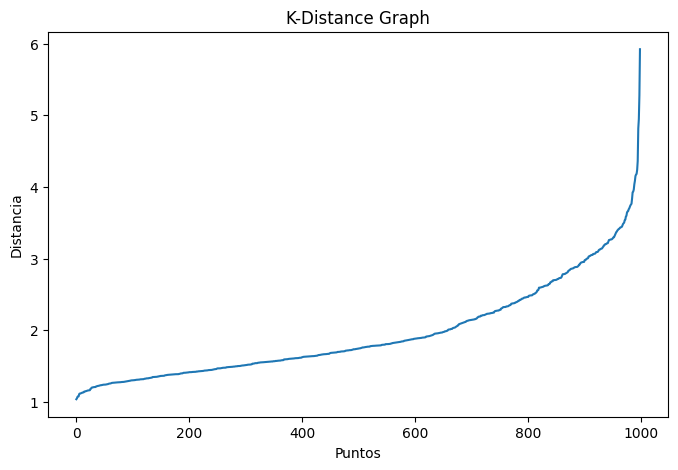

In [27]:
plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title('K-Distance Graph')
plt.xlabel('Puntos')
plt.ylabel('Distancia')

plt.show()

## Selección del parámetro eps

El parámetro eps fue seleccionado mediante el análisis del gráfico K-Distance utilizando 5 vecinos más cercanos.

Se observó un cambio pronunciado en la pendiente de la curva alrededor de una distancia cercana a 3.0, indicando la transición entre regiones densas y observaciones potencialmente atípicas.

Por esta razón se seleccionó un valor de eps = 3.0 para la ejecución del algoritmo DBSCAN.

# Paso 12: Aplicación de DBSCAN

A diferencia de K-Means, DBSCAN no requiere especificar previamente el número de clusters.

Este algoritmo identifica regiones densas de observaciones utilizando dos parámetros:

- eps: distancia máxima para considerar vecinos.
- min_samples: número mínimo de observaciones para formar una región densa.

El valor de eps fue seleccionado mediante el análisis del gráfico K-Distance.

In [28]:
dbscan = DBSCAN(
    eps=2.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

print(np.unique(db_labels, return_counts=True))

(array([-1,  0,  1,  2]), array([123, 860,  14,   3]))


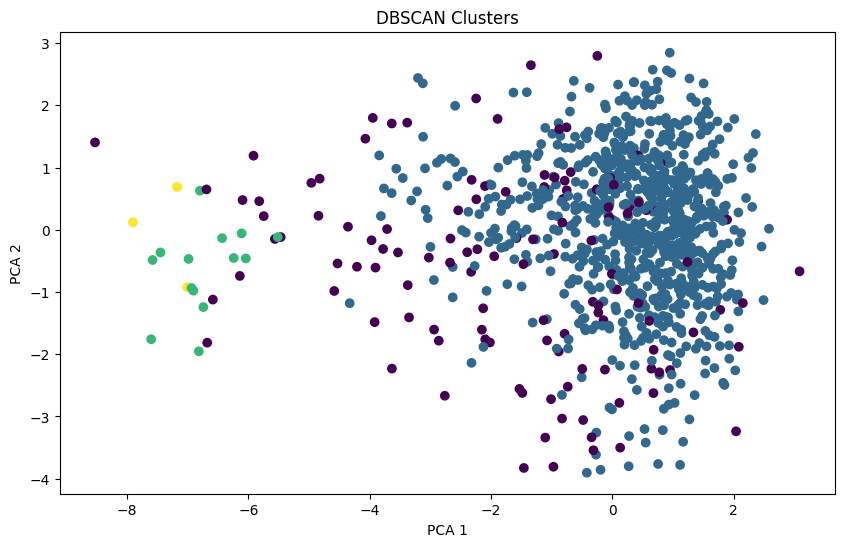

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap='viridis'
)

plt.title('DBSCAN Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

## Resultados obtenidos con DBSCAN

Al aplicar DBSCAN se identificó una región densa dominante que agrupa la mayoría de las canciones del conjunto de datos.

Adicionalmente, el algoritmo detectó observaciones clasificadas como ruido (outliers), correspondientes a canciones con características menos frecuentes dentro del dataset.

Los clusters secundarios encontrados fueron muy pequeños en comparación con el cluster principal, lo que sugiere que la estructura de densidad de los datos no favorece una segmentación natural mediante DBSCAN.

Los resultados indican que la estructura del conjunto de datos favorece una segmentación mediante K-Means, mientras que DBSCAN resulta especialmente útil para identificar canciones atípicas.

# Paso 13: Comparación entre K-Means y DBSCAN

K-Means produjo tres segmentos musicales claramente diferenciados:

- Música popular y bailable.
- Música acústica e instrumental.
- Música energética y rápida.

Por otro lado, DBSCAN identificó principalmente una única región densa junto con algunas canciones atípicas.

Estos resultados sugieren que K-Means ofrece una segmentación más útil para aplicaciones de negocio como sistemas de recomendación y generación automática de playlists, mientras que DBSCAN resulta más adecuado para la detección de observaciones inusuales.

In [30]:
df['DBSCAN_Cluster'] = db_labels
df.groupby('DBSCAN_Cluster')[features].mean()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
DBSCAN_Cluster,,,,,,,,,,,,
-1,28.243902,0.553642,0.569817,5.455285,-10.891878,0.552846,0.163246,0.447971,0.395978,0.241615,0.461617,124.738407
0,64.006977,0.627020,0.684738,5.265116,-6.261207,0.618605,0.082024,0.226027,0.013963,0.182743,0.531534,121.951502
1,52.142857,0.230143,0.107479,2.142857,-24.718929,0.928571,0.046707,0.962143,0.810357,0.115750,0.171793,110.265929
2,59.666667,0.291000,0.031633,4.666667,-29.989667,0.000000,0.042700,0.962000,0.880667,0.103867,0.112700,126.203000


# Paso 14: Aplicaciones comerciales

Los clusters identificados pueden utilizarse para mejorar sistemas de recomendación musical.

- Cluster 0: playlists de tendencias y éxitos comerciales.
- Cluster 1: playlists de concentración, relajación o estudio.
- Cluster 2: playlists para entrenamiento físico o actividades de alta energía.

La segmentación permite personalizar la experiencia del usuario y mejorar la curación automática de contenido.

Estos resultados demuestran cómo las técnicas de aprendizaje no supervisado pueden apoyar la toma de decisiones en plataformas de streaming mediante la personalización de recomendaciones y la organización automática de contenido.

# Conclusiones

1. Se aplicó un proceso completo de aprendizaje no supervisado que incluyó preprocesamiento, reducción de dimensionalidad mediante PCA y segmentación utilizando K-Means y DBSCAN.

2. K-Means permitió identificar tres grupos de canciones con características musicales claramente diferenciadas, facilitando su interpretación y posible uso en sistemas de recomendación.

3. Aunque el Silhouette Score presentó su mejor valor para K=2, la combinación del Método del Codo, la visualización mediante PCA y la interpretación de los clusters justificó la elección de K=3.

4. DBSCAN permitió identificar canciones atípicas (ruido), aunque no generó una segmentación tan útil como K-Means para este conjunto de datos.

5. La segmentación obtenida podría utilizarse para personalizar recomendaciones musicales, construir playlists temáticas y mejorar la experiencia de los usuarios en plataformas de streaming.

### Finalmente, este ejercicio permitió comprender que diferentes algoritmos de clustering pueden producir resultados distintos sobre un mismo conjunto de datos, por lo que la selección del algoritmo debe basarse tanto en métricas cuantitativas como en la interpretación del problema de negocio.